# 11. Numerical computing (scipy) — homework

### Exercise 11.1 (heat)
Solve the 1D heat equation with initial and bondary conditions not used during the classes. Send the script and the figure. 

In [1]:
import scipy as sp

r = 0.15999999999999998
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.03503484 0.03506995 0.03510529]
 [0.         0.         0.         ... 0.07028916 0.07036073 0.0704327 ]
 ...
 [0.         0.         0.0256     ... 0.86219913 0.86239741 0.8625941 ]
 [0.         0.16       0.2688     ... 0.93078166 0.93088339 0.93098429]
 [1.         1.         1.         ... 1.         1.         1.        ]]


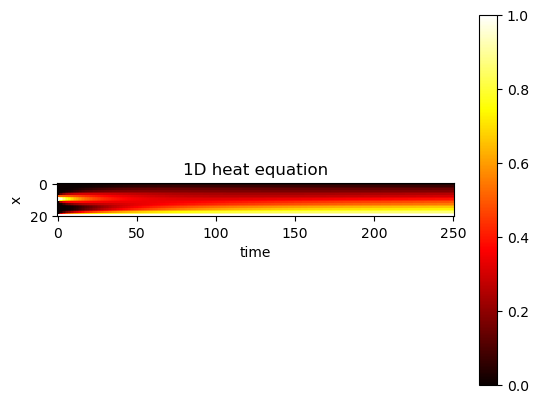

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

#D, Nx, Nt, L, T = 1.0, 14, 100, 1.0, 0.1
D, Nx, Nt, L, T = 1.0, 20, 250, 1.0, 0.1
#D, Nx, Nt, L, T = 1.0, 40, 500, 1.0, 0.1
t = np.linspace(0, T, num=Nt+1, dtype=float)
x = np.linspace(0, L, num=Nx+1, dtype=float)
dx = x[1] - x[0]
dt = t[1] - t[0]
r = D*dt / (dx*dx)
print ( "r = {}".format(r) )
assert r < 0.5

#u = np.zeros( (Nx+1,Nt+1), dtype=float )  # macierz na wszystkie wyniki
u = np.empty( (Nx+1,Nt+1), dtype=float )  # macierz na wszystkie wyniki

# initial condition, t=0
#u[:,0] = 4.0 * x * (1-x)   # arc
#u[:,0] = 0.5*(np.sign(x-0.4) + np.sign(0.6 - x)) # step
#u[:,0] = np.where(x < 0.5, 2*x, 2*(1-x))
#u[:,0] = np.where(x < 0.5, 0, 1)
#u[:,0] = 0.0   # cold rod

# boundary condition, x=0 and x=L=1
u[0,:] = 0.0   # cold end
#u[Nx,:] = 0.0   # cold end
u[Nx,:] = 1.0   # hot end

# iteration/solution the linear algebraic equations
for j in range(Nt):
    #for i in range(1,Nx):
    #    u[i,j+1] = r*u[i-1,j] + (1-2*r)*u[i,j] + r*u[i+1,j]
    # vectorization
    u[1:-1,j+1] = r*u[:-2,j] + (1-2*r)*u[1:-1,j] + r*u[2:,j]

# visualization
print ( u )
plt.title("1D heat equation")
plt.xlabel("time") # odwrotnie!
plt.ylabel("x")

plt.imshow(u, cmap='hot', interpolation='nearest')
#plt.imshow(u[:,::3], cmap='hot', interpolation='nearest')
#plt.imshow(u[:,::3], cmap='hot', interpolation='bilinear')
#plt.imshow(u[:,::3], cmap='hot', interpolation='hamming')
#plt.imshow(u[:,::5], cmap='hot', interpolation='nearest')

plt.colorbar()
plt.show()

### Exercise 11.2 (wave)
Solve the 1D wave equation with initial and bondary conditions not used during the classes. Send the script and the figure.

Note that u[:,0] (the initial position of the strig) should be continous and consistent with boundary conditions. In the case of Dirichlet conditions the string ends are fixed, u[0,:] = 0 and u[Nx,:] = 0. 

r = 0.15999999999999998


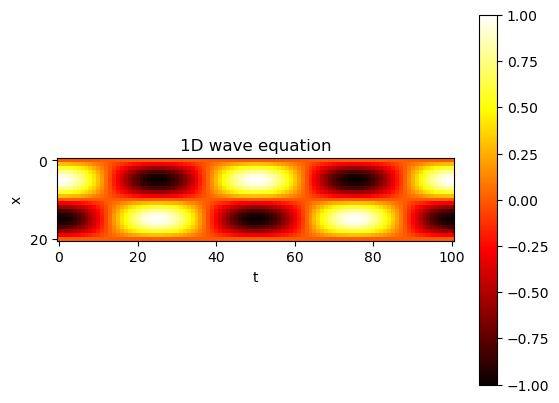

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Given mesh points as arrays x and t (x[i], t[j])
Nx, Nt, L, T, c = 20, 100, 1.0, 2.0, 1.0
t = np.linspace(0, T, num=Nt+1, dtype=float)   # t in [0,T]
x = np.linspace(0, L, num=Nx+1, dtype=float)   # x in [0,L]
dx = x[1] - x[0]
dt = t[1] - t[0]
#Nt = len(t)-1
#Nx = len(x)-1
r = (c*dt/dx)**2
print ( "r = {}".format(r) )
assert r < 1

#u = np.zeros( (Nx+1,Nt+1), dtype=float )  # all results
u = np.empty( (Nx+1,Nt+1), dtype=float )  # all results

# initial condition, t=0, j=0
# initial shape of the string
#u[:,0] = np.where(x < 0.5, 2*x, 2*(1-x))
#u[:,0] = np.where(3*x < 1, 3*x, 1.5*(1-x))
#u[:,0] = np.abs(2*x-1)-1
#u[:,0] = np.where(x < 0.5, np.where(3*x<1, 3*x, 1), np.where(3*x<2, 1, 3*(1-x)))
#u[:,0] = np.sin(x * np.pi)
u[:,0] = np.sin(x * (np.pi * 2))

#assert u[0,0] == 0 and u[Nx,0] == 0
assert abs(u[0,0]) < 1e-6 and abs(u[Nx,0]) < 1e-6

# boundary condition, x=0 and x=L
u[0,:] = 0.0
u[Nx,:] = 0.0

#for i in range(1,Nx):   # initial condition j=1
#    u[i,1] = u[i,0] + (r*0.5)*( u[i-1,0] -2*u[i,0] + u[i+1,0] )
u[1:-1,1] = u[1:-1,0] + (r*0.5)*( u[:-2,0] -2*u[1:-1,0] + u[2:,0] )

# iteration/solution the linear algebraic equations
for j in range(1,Nt):
    #for i in range(1,Nx):
    #    u[i,j+1] = -u[i,j-1] +2*u[i,j] + r*(u[i-1,j] -2*u[i,j] + u[i+1,j])
    u[1:-1,j+1] = -u[1:-1,j-1] +2*u[1:-1,j] + r*(u[:-2,j] -2*u[1:-1,j] + u[2:,j])

# visualization
plt.title("1D wave equation")
plt.xlabel("t")
plt.ylabel("x")

plt.imshow(u, cmap='hot', interpolation='nearest')
#plt.imshow(u[:,::3], cmap='hot', interpolation='nearest')
#plt.imshow(u[:,::3], cmap='hot', interpolation='bilinear')
#plt.imshow(u[:,::3], cmap='hot', interpolation='hamming')

plt.colorbar()
plt.show()